--- First 5 Rows of the Dataset ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


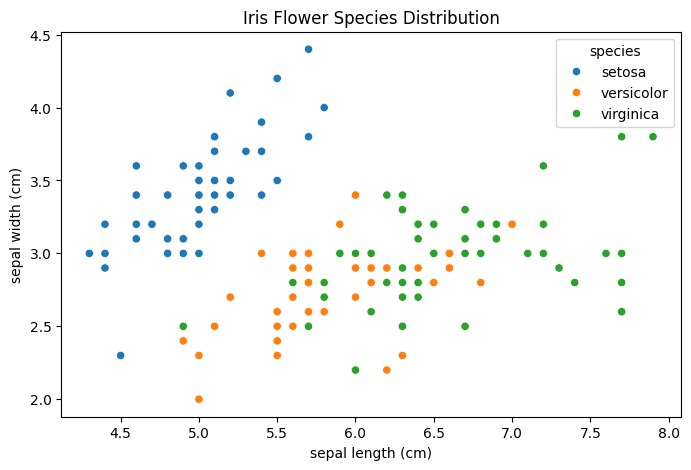


--- Model Performance Evaluation ---
Accuracy Score: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



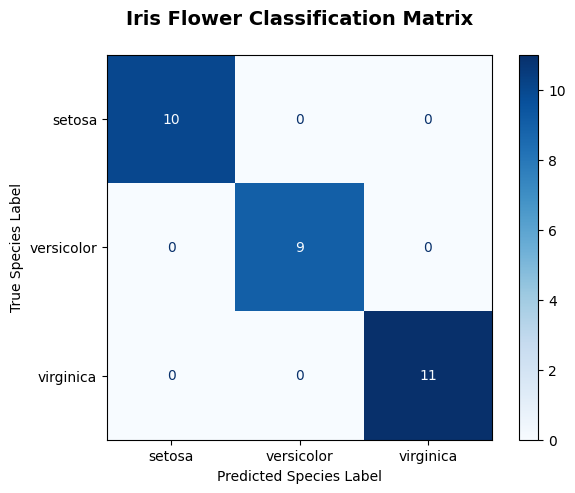

In [2]:
# 1. Import the necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 2. Load the built-in Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# 3. Quick Data Visualization
print("--- First 5 Rows of the Dataset ---")
print(df.head())

# --- CHART 1: Your Original Scatter Plot ---
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)', hue='species')
plt.title('Iris Flower Species Distribution')
plt.show()

# 4. Split the data into Training and Testing sets
X = df.drop('species', axis=1)
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train the Machine Learning Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 6. Test the Model and Print Results
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n--- Model Performance Evaluation ---")
print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# --- CHART 2: Professional Confusion Matrix Heatmap ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues, ax=plt.gca())

plt.title("Iris Flower Classification Matrix\n", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Species Label")
plt.ylabel("True Species Label")
plt.show()